Epoch 0 | Train Loss: 0.655085 | Val Loss: 0.506954
Epoch 20 | Train Loss: 0.401140 | Val Loss: 0.303198
Epoch 40 | Train Loss: 0.383783 | Val Loss: 0.295944
Epoch 60 | Train Loss: 0.369783 | Val Loss: 0.300291
Epoch 80 | Train Loss: 0.356979 | Val Loss: 0.299486

Best model at epoch 36 with val loss 0.288140
torch.Size([200, 2]) torch.Size([200, 1])
accuracy: 0.875


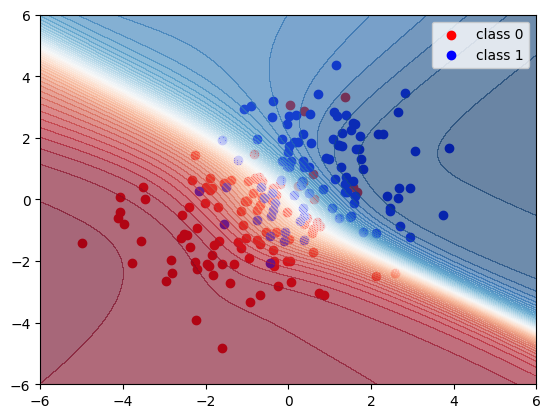

In [9]:
#classification model

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

c0 = torch.randn(100, 2) * 1.5 + torch.tensor([-1.0, -1.0])
c1 = torch.randn(100, 2) * 1.5 + torch.tensor([1.0, 1.0])

x=torch.cat([c0,c1],dim=0)
y=torch.cat([torch.zeros(100),torch.ones(100)]).view(-1,1)

indices=torch.randperm(x.shape[0])
x=x[indices]
y=y[indices]

split=int(0.8*len(x))
x_train, x_val= x[:split], x[split:]
y_train, y_val= y[:split], y[split:]


class net(nn.Module):
  def __init__(self):
    super(net,self).__init__()
    self.input=nn.Linear(2,16)
    self.l1=nn.Linear(16,16)
    self.output=nn.Linear(16,1)
    self.dropout=nn.Dropout(0.3)

  def forward(self,X):
    x=torch.tanh(self.input(X))
    self.dropout(x)
    x=torch.tanh(self.l1(x))
    self.dropout(x)

    return self.output(x)

model=net()
criterion=nn.BCEWithLogitsLoss()
optimizer=optim.Adam(model.parameters(),lr=0.01)

train_losses=[]
val_losses=[]

best_val_loss=float('inf')
best_epoch=0

dataset=TensorDataset(x_train,y_train)
dataloader=DataLoader(dataset,batch_size=32,shuffle=True)

for epoch in range(100):
  model.train()
  epoch_loss=0

  for batch_x, batch_y in dataloader:
      optimizer.zero_grad()
      ypred=model(batch_x)
      loss=criterion(ypred,batch_y)
      loss.backward()
      torch.nn.utils.clip_grad_norm_(model.parameters(),max_norm=1.0)
      optimizer.step()
      epoch_loss+=loss.item()

  avg_train_loss=epoch_loss/len(dataloader)
  train_losses.append(avg_train_loss)

  model.eval()

  with torch.no_grad():
      val_pred=model(x_val)
      val_loss=criterion(val_pred,y_val)
      pred_class=(val_pred>0.0).float()
      accuracy=(pred_class==y_val).float().mean()
      val_losses.append(val_loss.item())

  if val_loss<best_val_loss:
    best_val_loss=val_loss
    best_epoch=epoch
    torch.save(model.state_dict(),'best_model.pt')

  if epoch % 20 == 0:
    print(f'Epoch {epoch} | Train Loss: {avg_train_loss:.6f} | Val Loss: {val_loss:.6f}')

model.load_state_dict(torch.load('best_model.pt'))
print(f'\nBest model at epoch {best_epoch} with val loss {best_val_loss:.6f}')

print(x.shape,y.shape)
print('accuracy:',accuracy.item())

gx=torch.linspace(-6,6,100)
gy=torch.linspace(-6,6,100)
GX,GY=torch.meshgrid(gx,gy,indexing='ij')
grid=torch.stack([GX.flatten(),GY.flatten()],dim=1)

with torch.no_grad():
  pred=torch.sigmoid(model(grid)).reshape(100,100)

plt.scatter(c0[:,0],c0[:,1],label='class 0',c='red')
plt.scatter(c1[:,0],c1[:,1],label='class 1',c='blue')
plt.contourf(GX.numpy(),GY.numpy(),pred.numpy(),levels=50,cmap='RdBu',alpha=0.6)
plt.legend()
plt.show()

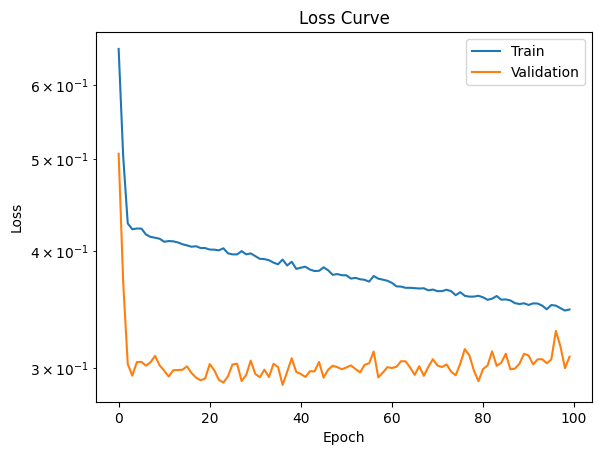

In [10]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curve')
plt.show()

In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

model.eval()
with torch.no_grad():
    val_pred = model(x_val)
    pred_class = (val_pred > 0.0).float()

print(classification_report(y_val.numpy(), pred_class.numpy()))

cm = confusion_matrix(y_val.numpy(), pred_class.numpy())
print('Confusion Matrix:')
print(cm)

              precision    recall  f1-score   support

         0.0       0.89      0.94      0.91        17
         1.0       0.95      0.91      0.93        23

    accuracy                           0.93        40
   macro avg       0.92      0.93      0.92        40
weighted avg       0.93      0.93      0.93        40

Confusion Matrix:
[[16  1]
 [ 2 21]]


Observations:

1. Overlapping classes create irreducible error — no model can get 100% accuracy
2. Overfitting on classification looks like a chaotic decision boundary, not just a rising val loss
3. Dropout regularizes by making training harder — val loss can be lower than train loss, and that's normal
4. The confusion matrix is the foundation of all classification metrics
5. Precision = how many of your positive predictions were right
6. Recall = how many actual positives did you catch
7. Which matters more depends on your problem — in HEP, missing a rare signal (low recall) is usually worse than a false alarm